In [3]:
import pandas as pd
from pathlib import Path

file_path = Path.home() / "Downloads" / "dec 2024 data.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)

       Date Carrier  Airline Name  Flight_Num Origin Dest  Dep_Time  \
0  12/31/24      9E  Endeavor Air        4780    ATL  TUL       820   
1  12/31/24      9E  Endeavor Air        4780    TUL  ATL      1018   
2  12/31/24      9E  Endeavor Air        4781    ATL  MDT      1110   
3  12/31/24      9E  Endeavor Air        4781    MDT  ATL      1350   
4  12/31/24      9E  Endeavor Air        4783    MDT  ATL       600   

   Actual_Dep  Delay  Cancelled  
0       819.0   -1.0          0  
1      1021.0    3.0          0  
2      1106.0   -4.0          0  
3      1342.0   -8.0          0  
4       607.0    7.0          0  
Index(['Date', 'Carrier', 'Airline Name', 'Flight_Num', 'Origin', 'Dest',
       'Dep_Time', 'Actual_Dep', 'Delay', 'Cancelled'],
      dtype='object')


In [4]:
df = df[df['Cancelled'] == 0]

df['Cancelled'].value_counts()

0    627365
Name: Cancelled, dtype: int64

In [5]:
df['Delayed'] = (df['Delay'] > 15).astype(int)

df[['Delay', 'Delayed']].head()

,Delay,Delayed
0,-1.0,0
1,3.0,0
2,-4.0,0
3,-8.0,0
4,7.0,0


In [6]:
df_svm = df.sample(n=30000, random_state=42)

In [7]:
df_svm.shape

(30000, 11)

In [8]:
y_svm = df_svm['Delayed']

X_svm = df_svm.drop(['Delayed', 'Delay'], axis=1)

In [9]:
X_svm = X_svm.drop(['Actual_Dep', 'Flight_Num', 'Airline Name'], axis=1)

In [10]:
X_svm['Date'] = pd.to_datetime(X_svm['Date'])

X_svm['Month'] = X_svm['Date'].dt.month
X_svm['DayOfWeek'] = X_svm['Date'].dt.dayofweek

X_svm = X_svm.drop('Date', axis=1)

In [11]:
X_svm = pd.get_dummies(X_svm, drop_first=True)

In [12]:
from sklearn.model_selection import train_test_split

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_svm_scaled = scaler.fit_transform(X_train_svm)
X_test_svm_scaled = scaler.transform(X_test_svm)

In [14]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train_svm_scaled, y_train_svm)

/Users/brandonboyle/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_svm = svm_model.predict(X_test_svm_scaled)

print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))
print(classification_report(y_test_svm, y_pred_svm))

Accuracy: 0.6075
              precision    recall  f1-score   support

           0       0.84      0.62      0.72      4771
           1       0.27      0.55      0.37      1229

    accuracy                           0.61      6000
   macro avg       0.56      0.59      0.54      6000
weighted avg       0.73      0.61      0.64      6000



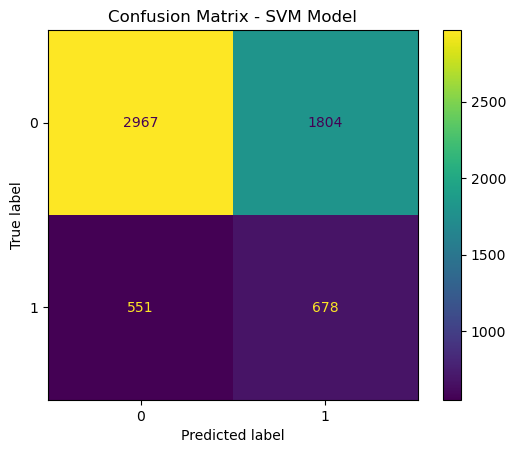

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test_svm, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()

plt.title("Confusion Matrix - SVM Model")
plt.show()
